In [79]:
#Loading datasets and importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

data = pd.read_csv("../datasets/yield_df.csv")
data.head()


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [80]:
#checking the dataset shape
data.shape

(28242, 8)

In [81]:
#Data cleaning
#checking dataset information
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  str    
 2   Item                           28242 non-null  str    
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), str(2)
memory usage: 1.7 MB


In [82]:
#checking the missing values
data.isnull().sum()

Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

In [85]:
#removing unnamed index column
data = data.drop(columns=["Unnamed: 0"])

In [90]:
#showing now datasets columns after removing unwanted column i.e unnamed
data.columns

Index(['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='str')

In [89]:
# #check the duplicate row values 
data.duplicated().sum()

np.int64(2310)

In [95]:
#dataset statistics

data.describe()

,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


In [ ]:
#converting to lower string and also data rice paddy to only rice
data["Item"] = data["Item"].str.lower()

data["Item"] = data["Item"].replace({
    "rice, paddy": "rice"
})

In [ ]:
#checking the data values of Item column
data["Item"].unique()

<StringArray>
[               'maize',             'potatoes',                 'rice',
              'sorghum',             'soybeans',                'wheat',
              'cassava',       'sweet potatoes', 'plantains and others',
                 'yams']
Length: 10, dtype: str

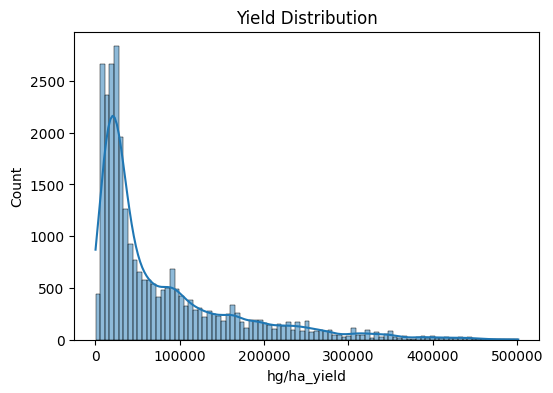

In [98]:
#EDA - Exploratory Data Analysis
#Yield Distribution

plt.figure(figsize=(6,4))
sns.histplot(data['hg/ha_yield'], kde=True)
plt.title("Yield Distribution")
plt.show()


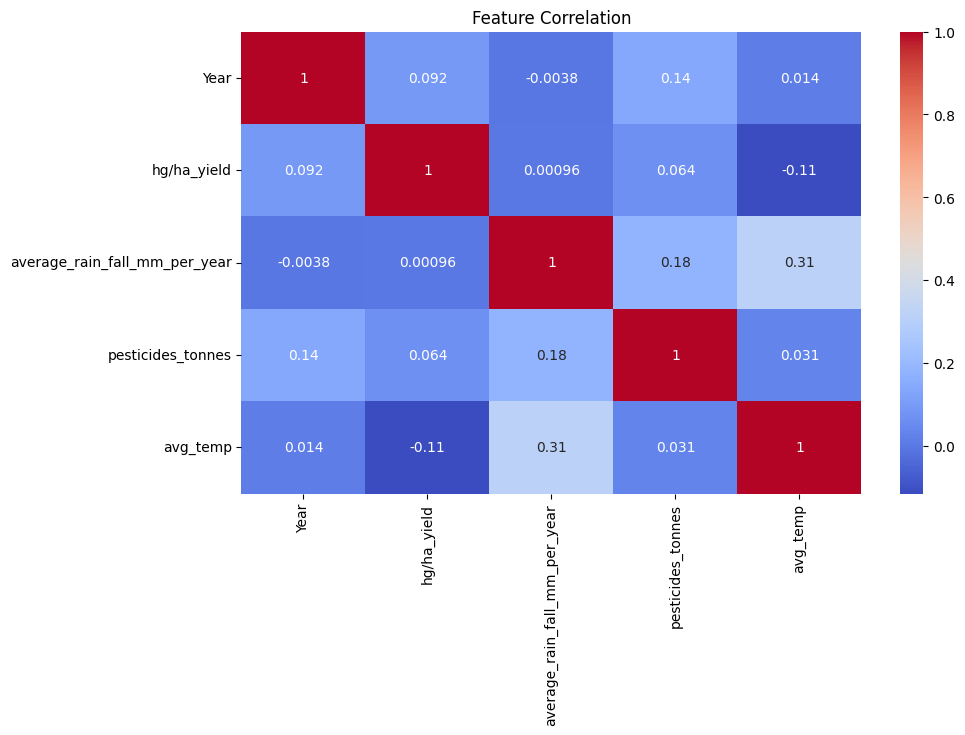

In [99]:
#Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

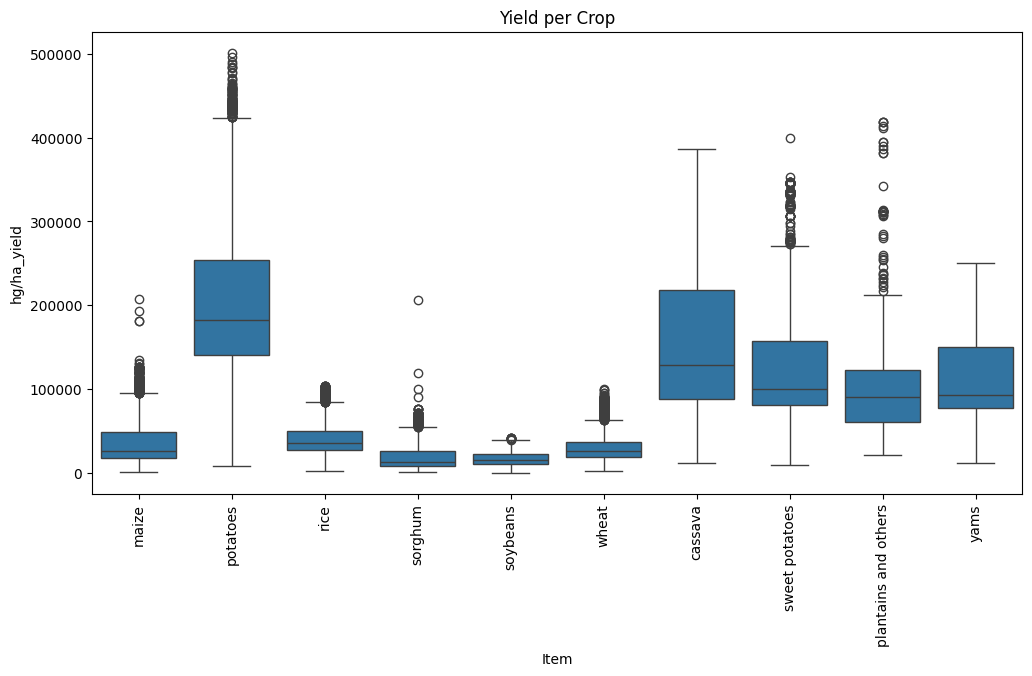

In [100]:
#crop vs yield
# plt.figure(figsize=(8,5))
# sns.boxplot(x="Item", y="hg/ha_yield", data = data)
# plt.title("Yield per Crop")
# plt.show()


plt.figure(figsize=(12,6))
sns.boxplot(x="Item", y="hg/ha_yield", data=data)

plt.xticks(rotation=90)
plt.title("Yield per Crop")
plt.show()

In [101]:
# Features selection and label encoding of categorical columns
#Encode crop column i.e Item
# encoder = LabelEncoder()

# data["Item"] = encoder.fit_transform(data["Item"])

le_area = LabelEncoder()
le_item = LabelEncoder()

data["Area"] = le_area.fit_transform(data["Area"])
data["Item"] = le_item.fit_transform(data["Item"])

In [102]:
#checking the values in numbers instead of country/crops names in string
data.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,1,1990,36613,1485.0,121.0,16.37
1,0,3,1990,66667,1485.0,121.0,16.37
2,0,4,1990,23333,1485.0,121.0,16.37
3,0,5,1990,12500,1485.0,121.0,16.37
4,0,6,1990,7000,1485.0,121.0,16.37


In [103]:
#separate features and target
X = data.drop("hg/ha_yield", axis=1)
y = data["hg/ha_yield"]

In [104]:
#Train and Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [105]:
#Train multiple models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=200)
}

results = {}

In [106]:
#Train and Evaluation of models
for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    }

results_df = pd.DataFrame(results).T
results_df

,MAE,MSE,RMSE,R2 Score
Linear Regression,62444.310630,6.642538e+09,81501.764465,0.084252
Decision Tree,4044.836962,1.775404e+08,13324.428059,0.975524
Random Forest,3727.676126,1.019789e+08,10098.461593,0.985941


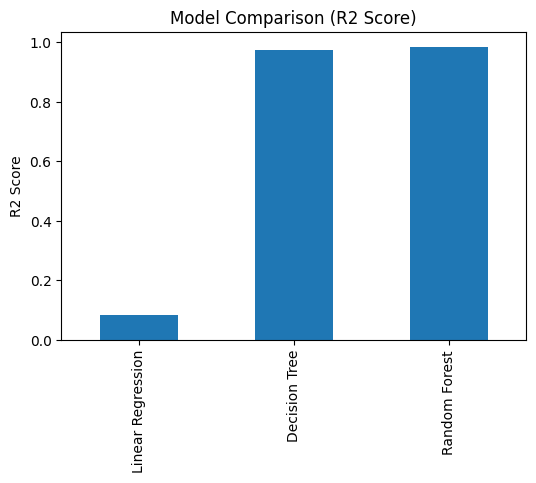

In [107]:
#comparison of models through visualization
results_df["R2 Score"].plot(kind="bar", figsize=(6,4))
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.show()

In [108]:
#comaparison and evaluation
#results_df.sort_values(by="R2 Score", ascending=False)

# best_model = results_df.loc[results_df["R2 Score"].idxmax()]
# print("Best Model:", best_model)

best_model = results_df["R2 Score"].idxmax()

print("Best Model:", best_model)

Best Model: Random Forest


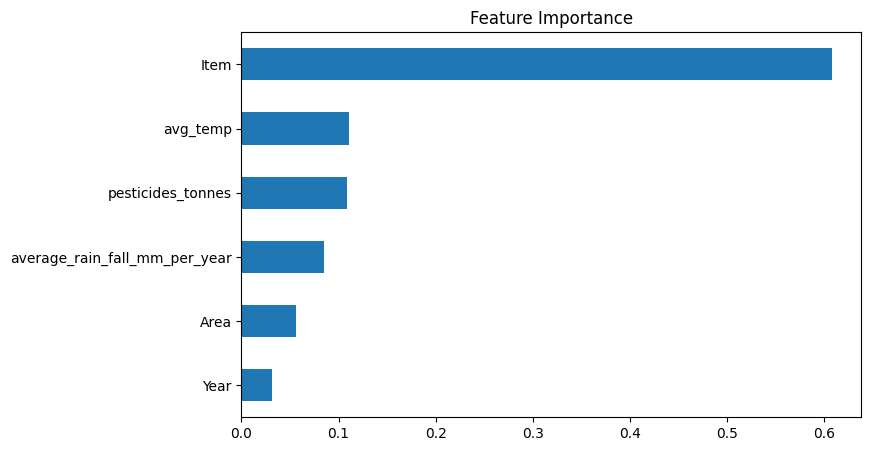

In [109]:
#features importances
rf_model = models["Random Forest"]

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Feature Importance")
plt.show()


In [110]:
#saving best model
final_model = models[best_model]

joblib.dump(final_model, "../ml_models/yield_prediction/yield_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
#checking the columns
data.columns

Index(['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='str')

In [ ]:
#Testing the prediction finally
sample = pd.DataFrame({
    "Area":[le_area.transform(["Nepal"])[0]],
    "Item":[le_item.transform(["rice"])[0]],
    "Year":[2013],
    "average_rain_fall_mm_per_year":[1200],
    "pesticides_tonnes":[200],
    "avg_temp":[25]
})

prediction = final_model.predict(sample)

print("Predicted Crop Yield:", prediction[0], "hg/ha_yield")

Predicted Crop Yield: 25749.755 hg/ha_yield


In [ ]:
#testing and comparison between predicted and actual values
y_pred = final_model.predict(X_test)

In [116]:
results = pd.DataFrame({
    "Actual Yield": y_test,
    "Predicted Yield": y_pred
})

results.head(10)

,Actual Yield,Predicted Yield
25564,69220,71315.640
18113,20000,24101.270
25607,51206,51126.425
6815,166986,164445.000
18144,56319,59241.340
12680,26163,26163.000
3474,30708,30702.100
22381,109771,109896.670
20656,241650,237802.635
23170,47500,46172.890


In [ ]:
#differences values of predicted and actual yield values
results["Error"] = results["Actual Yield"] - results["Predicted Yield"]

results.head(10)

,Actual Yield,Predicted Yield,Error
25564,69220,71315.640,-2095.640
18113,20000,24101.270,-4101.270
25607,51206,51126.425,79.575
6815,166986,164445.000,2541.000
18144,56319,59241.340,-2922.340
12680,26163,26163.000,0.000
3474,30708,30702.100,5.900
22381,109771,109896.670,-125.670
20656,241650,237802.635,3847.365
23170,47500,46172.890,1327.110


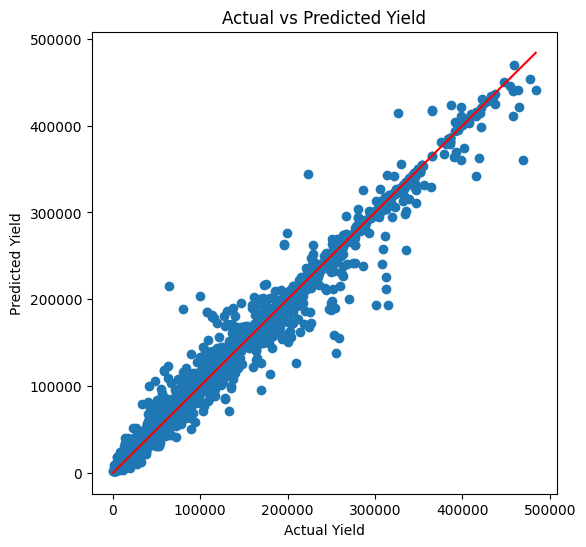

In [ ]:
#visualization of actual vs predicted yield values
plt.figure(figsize=(6,6))
plt.scatter(results["Actual Yield"], results["Predicted Yield"])

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")

plt.plot([results["Actual Yield"].min(), results["Actual Yield"].max()],
         [results["Actual Yield"].min(), results["Actual Yield"].max()],
         color='red')

plt.show()

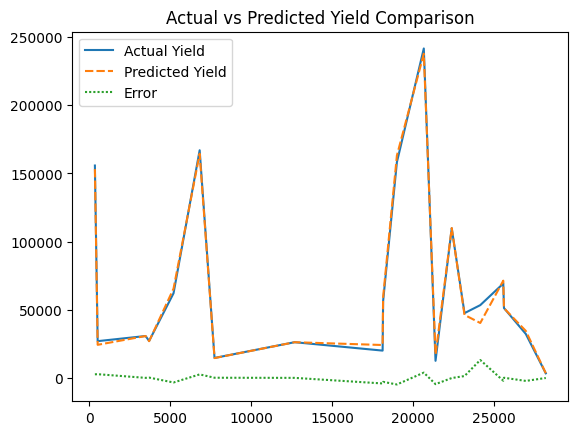

In [ ]:
#visualization of comparison between predicted and actual yield values
sns.lineplot(data=results.head(20))
plt.title("Actual vs Predicted Yield Comparison")
plt.show()

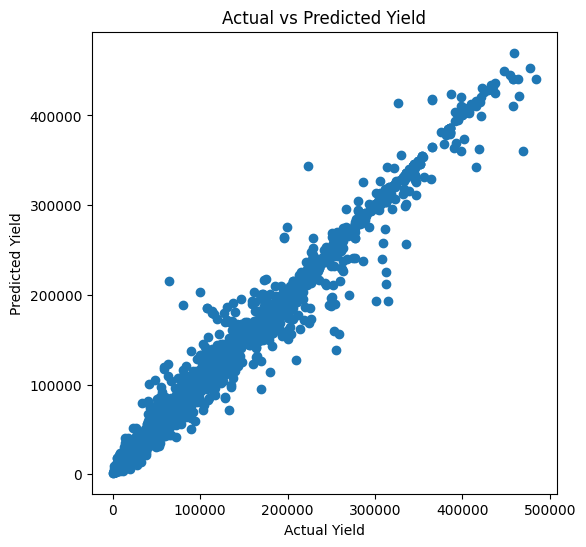

In [120]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")
plt.show()

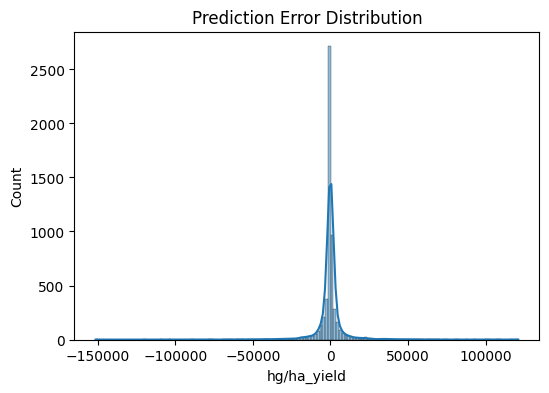

In [ ]:
#visualization of prediction error distribution
errors = y_test - y_pred

plt.figure(figsize=(6,4))
sns.histplot(errors, kde=True)
plt.title("Prediction Error Distribution")
plt.show()

In [122]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 3727.676125862985
MSE: 101978926.54365735
RMSE: 10098.461592918862
R2 Score: 0.9859410617197386


In [125]:
#testing the results by inputting the new raw datas
sample = pd.DataFrame({
    "Area":[le_area.transform(["India"])[0]],
    "Item":[le_item.transform(["wheat"])[0]],
    "Year":[2013],
    "average_rain_fall_mm_per_year":[1200],
    "pesticides_tonnes":[200],
    "avg_temp":[25]
})

prediction = final_model.predict(sample)

print("Predicted Yield:", prediction[0], "hg/ha_yield")

Predicted Yield: 18237.825 hg/ha_yield
